# Document Image Classification using Lightweight CNNs
## with OCR-based Deep Learning Baseline

**Project:** Compare CNN image classification vs OCR + PyTorch MLP text classification  
**Framework:** PyTorch (all deep learning models)  
**Platform:** Windows / Local

---

###  Notebook Map
| Section | Description |
|---------|-------------|
| 1 | Setup & Imports |
| 2 | Configuration — Data|
| 3 | Dataset Loading (ImageFolder) |
| 4 | CNN Pipeline (MobileNetV2) |
| 5 | OCR Text Extraction |
| 6 | OCR-MLP Pipeline (PyTorch) |
| 7 | Evaluation & Comparison |


---
##  Section 1 — Setup & Imports

**Before running:**
1. Install Tesseract OCR (Windows): https://github.com/UB-Mannheim/tesseract/wiki
2. Set `tesseract_cmd` path in Section 2 if needed
3. Run `pip install torch torchvision pytesseract opencv-python scikit-learn tqdm matplotlib seaborn pillow` in your terminal

In [ ]:
# ── Standard library ──────────────────────────────────────────────────────────
import os, sys, re, json, pickle, random, shutil, tempfile, warnings
from pathlib import Path
from collections import defaultdict

# ── Third-party ───────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
from tqdm.notebook import tqdm

# ── OpenCV ────────────────────────────────────────────────────────────────────
import cv2

# ── OCR ───────────────────────────────────────────────────────────────────────
import pytesseract

# ── Sklearn (TF-IDF only) ─────────────────────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

# ── PyTorch ───────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torchvision import datasets, transforms, models
from torchvision.models import MobileNet_V2_Weights

warnings.filterwarnings('ignore')

# ── Device setup ──────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch version : {torch.__version__}')
print(f'Device          : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU             : {torch.cuda.get_device_name(0)}')
else:
    print('  → Running on CPU. Training will be slower.')
    print('  → Tip: set NUM_EPOCHS lower for a quick test run.')

PyTorch version : 2.11.0+cpu
Device          : cpu
  → Running on CPU. Training will be slower.
  → Tip: set NUM_EPOCHS lower for a quick test run.


---
##  Section 2 — Configuration

> **Only edit this cell.** Point `DATA_DIR` to your dataset root.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#  ★  EDIT THESE  ★
# ─────────────────────────────────────────────────────────────────────────────

# Root folder containing train/, val/, test/ subfolders
DATA_DIR = r"C:\Users\DPQUAI250127\Documents\data\rvlcdip_preprocessed1"  # ← CHANGE THIS

# Windows Tesseract path — uncomment and adjust if tesseract is not on PATH
# pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'

# ── Training hyperparameters ──────────────────────────────────────────────────
NUM_EPOCHS_CNN  = 10
NUM_EPOCHS_MLP  = 10
BATCH_SIZE      = 32
LEARNING_RATE   = 1e-3
IMG_SIZE        = 224        # MobileNetV2 expects 224x224
RANDOM_SEED     = 42

# ── OCR cache (delete these files to force re-extraction) ────────────────────
OCR_CACHE_DIR   = 'ocr_cache'

# ── Output directories ────────────────────────────────────────────────────────
Path('results').mkdir(exist_ok=True)
Path('models').mkdir(exist_ok=True)
Path(OCR_CACHE_DIR).mkdir(exist_ok=True)

# ── Reproducibility ───────────────────────────────────────────────────────────
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if DEVICE.type == 'cuda':
    torch.cuda.manual_seed_all(RANDOM_SEED)

# ── Validate DATA_DIR ─────────────────────────────────────────────────────────
IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.tif', '.tiff', '.bmp'}
TRAIN_DIR  = Path(DATA_DIR) / 'train'
VAL_DIR    = Path(DATA_DIR) / 'val'
TEST_DIR   = Path(DATA_DIR) / 'test'

all_ok = True
for split_dir, name in [(TRAIN_DIR, 'train'), (VAL_DIR, 'val'), (TEST_DIR, 'test')]:
    if not split_dir.exists():
        print(f'⚠  {name}/ not found at: {split_dir}')
        all_ok = False
    else:
        classes_found = [d.name for d in sorted(split_dir.iterdir()) if d.is_dir()]
        n_img = sum(1 for p in split_dir.rglob('*') if p.suffix.lower() in IMAGE_EXTS)
        print(f' {name:5s}: {len(classes_found)} classes, {n_img} images  →  {classes_found}')

if all_ok:
    CLASS_NAMES = [d.name for d in sorted(TRAIN_DIR.iterdir()) if d.is_dir()]
    NUM_CLASSES = len(CLASS_NAMES)
    print(f'\nNUM_CLASSES = {NUM_CLASSES}  |  Classes: {CLASS_NAMES}')

 train: 10 classes, 3497 images  →  ['ADVE', 'Email', 'Form', 'Letter', 'Memo', 'News', 'Note', 'Report', 'Resume', 'Scientific']
 val  : 10 classes, 748 images  →  ['ADVE', 'Email', 'Form', 'Letter', 'Memo', 'News', 'Note', 'Report', 'Resume', 'Scientific']
 test : 10 classes, 750 images  →  ['ADVE', 'Email', 'Form', 'Letter', 'Memo', 'News', 'Note', 'Report', 'Resume', 'Scientific']

NUM_CLASSES = 10  |  Classes: ['ADVE', 'Email', 'Form', 'Letter', 'Memo', 'News', 'Note', 'Report', 'Resume', 'Scientific']


---
##  Section 3 — Dataset Loading

We use `torchvision.datasets.ImageFolder` which expects the folder structure:
```
train/
  invoice/   img001.jpg  img002.jpg ...
  receipt/   img003.jpg  img004.jpg ...
  form/      img005.jpg  ...
```

Train samples : 3497
Val   samples : 748
Test  samples : 750
Classes       : ['ADVE', 'Email', 'Form', 'Letter', 'Memo', 'News', 'Note', 'Report', 'Resume', 'Scientific']


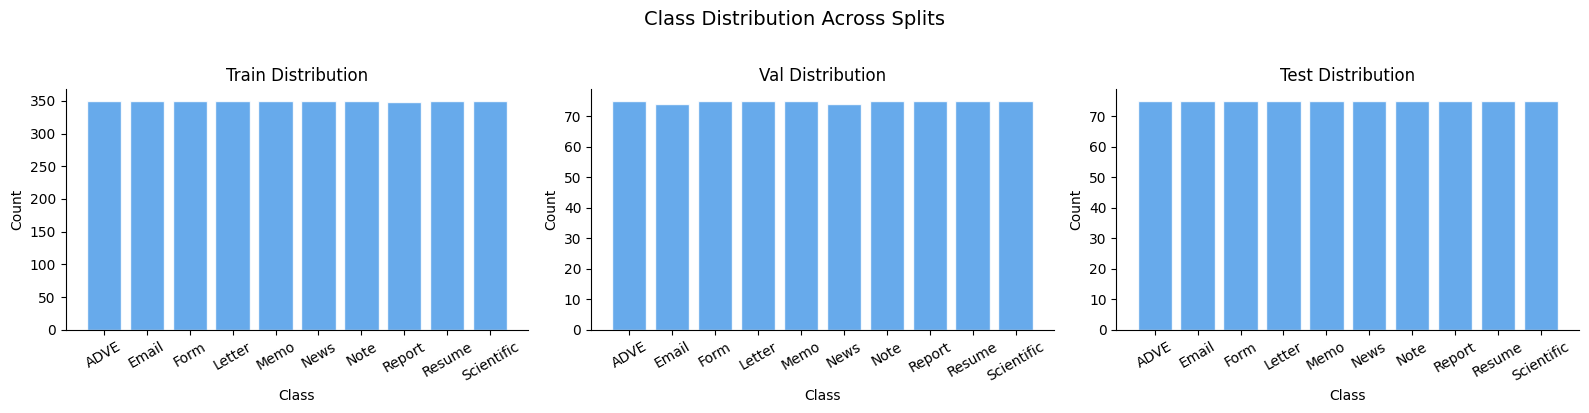

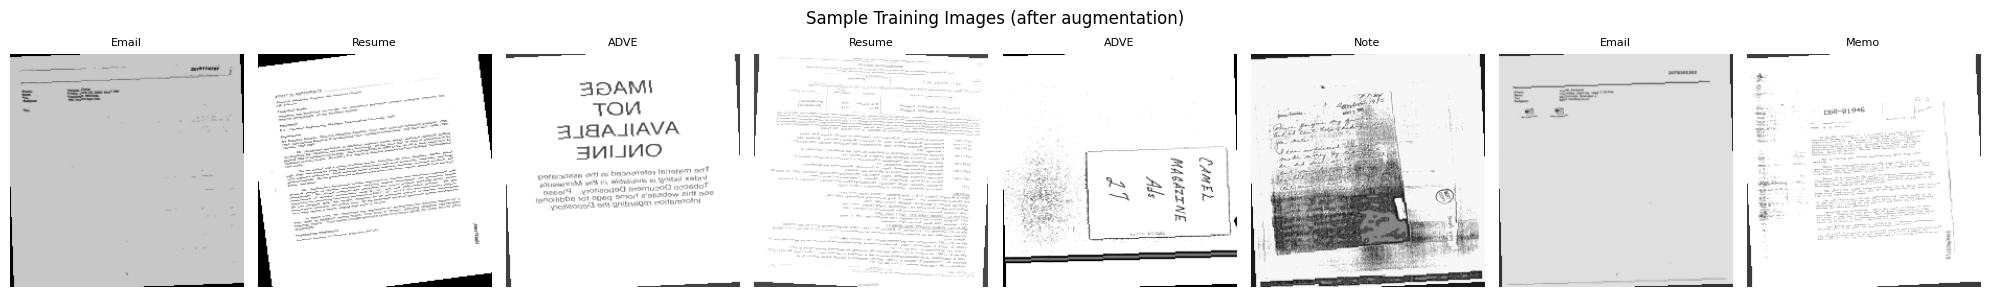

In [ ]:
# ── Image transforms ──────────────────────────────────────────────────────────
# Training: augmentation (flip, rotation, color jitter) to improve generalisation
# Val/Test: only resize + normalize (no randomness)

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# ── Datasets ──────────────────────────────────────────────────────────────────
train_dataset = datasets.ImageFolder(str(TRAIN_DIR), transform=train_transform)
val_dataset   = datasets.ImageFolder(str(VAL_DIR),   transform=eval_transform)
test_dataset  = datasets.ImageFolder(str(TEST_DIR),  transform=eval_transform)

# ── DataLoaders ───────────────────────────────────────────────────────────────
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0, pin_memory=False)

# ── Summary ───────────────────────────────────────────────────────────────────
print(f'Train samples : {len(train_dataset)}')
print(f'Val   samples : {len(val_dataset)}')
print(f'Test  samples : {len(test_dataset)}')
print(f'Classes       : {train_dataset.classes}')

# ── Class distribution bar chart ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, ds, title in zip(axes,
                          [train_dataset, val_dataset, test_dataset],
                          ['Train', 'Val', 'Test']):
    counts = defaultdict(int)
    for _, label in ds.samples:
        counts[ds.classes[label]] += 1
    ax.bar(counts.keys(), counts.values(), color='#4C9BE8', alpha=0.85, edgecolor='white')
    ax.set_title(f'{title} Distribution', fontsize=12)
    ax.set_xlabel('Class')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=30)
    ax.spines[['top','right']].set_visible(False)
plt.suptitle('Class Distribution Across Splits', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('results/class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Sample image grid ─────────────────────────────────────────────────────────
un_mean = torch.tensor(IMAGENET_MEAN).view(3,1,1)
un_std  = torch.tensor(IMAGENET_STD).view(3,1,1)

sample_imgs, sample_labels = next(iter(train_loader))
n_show = min(8, len(sample_imgs))
fig, axes = plt.subplots(1, n_show, figsize=(2.5 * n_show, 3))
for i, ax in enumerate(axes):
    img = (sample_imgs[i] * un_std + un_mean).clamp(0, 1)
    ax.imshow(img.permute(1, 2, 0).numpy())
    ax.set_title(train_dataset.classes[sample_labels[i]], fontsize=8)
    ax.axis('off')
plt.suptitle('Sample Training Images (after augmentation)', fontsize=12)
plt.tight_layout()
plt.savefig('results/sample_images.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Section 4 — CNN Pipeline (MobileNetV2)

We use **MobileNetV2** — a lightweight architecture designed for efficient image classification. We replace its final classifier layer to match our number of document classes.

**Strategy:** Fine-tune the full network (not frozen) since document images differ significantly from ImageNet.

In [ ]:
# ── Build MobileNetV2 ─────────────────────────────────────────────────────────
def build_cnn(num_classes: int) -> nn.Module:
    """
    MobileNetV2 pretrained on ImageNet.
    Last classifier layer replaced for our num_classes.
    """
    model = models.mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V1)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(p=0.2),
        nn.Linear(256, num_classes),
    )
    return model


cnn_model = build_cnn(NUM_CLASSES).to(DEVICE)

# Count parameters
total_params = sum(p.numel() for p in cnn_model.parameters())
trainable    = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
print(f'MobileNetV2 loaded')
print(f'  Total params    : {total_params:,}')
print(f'  Trainable params: {trainable:,}')
print(f'  Device          : {DEVICE}')

MobileNetV2 loaded
  Total params    : 2,554,378
  Trainable params: 2,554,378
  Device          : cpu


In [ ]:
# ── Loss, Optimizer, Scheduler ────────────────────────────────────────────────
cnn_criterion = nn.CrossEntropyLoss()
cnn_optimizer = optim.Adam(cnn_model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
cnn_scheduler = optim.lr_scheduler.StepLR(cnn_optimizer, step_size=4, gamma=0.5)


# ── Training & validation functions ───────────────────────────────────────────
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss    = criterion(outputs, labels)
            total_loss += loss.item() * imgs.size(0)
            preds       = outputs.argmax(1)
            correct    += (preds == labels).sum().item()
            total      += imgs.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return total_loss / total, correct / total, all_preds, all_labels


# ── CNN Training loop ─────────────────────────────────────────────────────────
print(f'Training CNN for {NUM_EPOCHS_CNN} epochs…\n')
cnn_history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_cnn_val_acc = 0.0

for epoch in range(1, NUM_EPOCHS_CNN + 1):
    tr_loss, tr_acc = train_one_epoch(
        cnn_model, train_loader, cnn_criterion, cnn_optimizer, DEVICE)
    vl_loss, vl_acc, _, _ = evaluate(
        cnn_model, val_loader, cnn_criterion, DEVICE)
    cnn_scheduler.step()

    cnn_history['train_loss'].append(tr_loss)
    cnn_history['val_loss'].append(vl_loss)
    cnn_history['train_acc'].append(tr_acc)
    cnn_history['val_acc'].append(vl_acc)

    if vl_acc > best_cnn_val_acc:
        best_cnn_val_acc = vl_acc
        torch.save(cnn_model.state_dict(), 'models/best_cnn.pth')
        saved_marker = ' ← saved'
    else:
        saved_marker = ''

    print(f'Epoch [{epoch:02d}/{NUM_EPOCHS_CNN}]  '
          f'Train Loss: {tr_loss:.4f}  Train Acc: {tr_acc:.4f}  '
          f'Val Loss: {vl_loss:.4f}  Val Acc: {vl_acc:.4f}{saved_marker}')

print(f'\n Best Val Accuracy (CNN): {best_cnn_val_acc:.4f}')

Training CNN for 10 epochs…

Epoch [01/10]  Train Loss: 1.4051  Train Acc: 0.5216  Val Loss: 1.2520  Val Acc: 0.5735 ← saved
Epoch [02/10]  Train Loss: 1.1008  Train Acc: 0.6340  Val Loss: 1.0962  Val Acc: 0.6430 ← saved
Epoch [03/10]  Train Loss: 1.0439  Train Acc: 0.6654  Val Loss: 0.9328  Val Acc: 0.6952 ← saved
Epoch [04/10]  Train Loss: 0.9630  Train Acc: 0.6912  Val Loss: 1.2078  Val Acc: 0.5922
Epoch [05/10]  Train Loss: 0.7803  Train Acc: 0.7524  Val Loss: 0.7530  Val Acc: 0.7527 ← saved
Epoch [06/10]  Train Loss: 0.7287  Train Acc: 0.7624  Val Loss: 0.7694  Val Acc: 0.7580 ← saved
Epoch [07/10]  Train Loss: 0.6606  Train Acc: 0.7941  Val Loss: 0.7429  Val Acc: 0.7807 ← saved
Epoch [08/10]  Train Loss: 0.6287  Train Acc: 0.7987  Val Loss: 0.7475  Val Acc: 0.7781
Epoch [09/10]  Train Loss: 0.5232  Train Acc: 0.8361  Val Loss: 0.6467  Val Acc: 0.8168 ← saved
Epoch [10/10]  Train Loss: 0.4692  Train Acc: 0.8516  Val Loss: 0.6544  Val Acc: 0.8048

 Best Val Accuracy (CNN): 0.8168


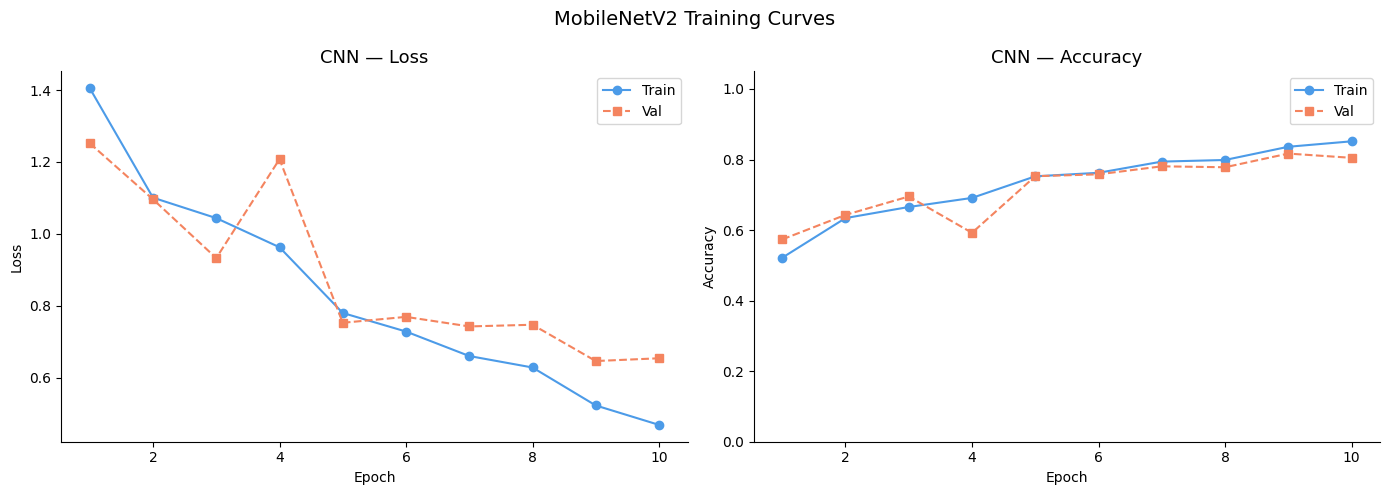

CNN Test Accuracy: 0.8107


In [ ]:
# ── CNN Training curves ───────────────────────────────────────────────────────
epochs_x = range(1, NUM_EPOCHS_CNN + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_x, cnn_history['train_loss'], 'o-', label='Train', color='#4C9BE8')
ax1.plot(epochs_x, cnn_history['val_loss'],   's--', label='Val',  color='#F4845F')
ax1.set_title('CNN — Loss', fontsize=13)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.spines[['top','right']].set_visible(False)

ax2.plot(epochs_x, cnn_history['train_acc'], 'o-', label='Train', color='#4C9BE8')
ax2.plot(epochs_x, cnn_history['val_acc'],   's--', label='Val',  color='#F4845F')
ax2.set_title('CNN — Accuracy', fontsize=13)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_ylim(0, 1.05); ax2.legend()
ax2.spines[['top','right']].set_visible(False)

plt.suptitle('MobileNetV2 Training Curves', fontsize=14)
plt.tight_layout()
plt.savefig('results/cnn_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Final test evaluation ─────────────────────────────────────────────────────
cnn_model.load_state_dict(torch.load('models/best_cnn.pth', map_location=DEVICE))
_, cnn_test_acc, cnn_preds, cnn_true = evaluate(
    cnn_model, test_loader, cnn_criterion, DEVICE)
print(f'CNN Test Accuracy: {cnn_test_acc:.4f}')

---
##  Section 5 — OCR Text Extraction

We use **Tesseract OCR** to convert document images into raw text. The extracted text is then cleaned and fed into a TF-IDF vectorizer before being passed to our PyTorch MLP.

> Results are cached to disk — delete `ocr_cache/` to force re-extraction.

In [ ]:
import os
import pytesseract

tess_path = r"C:\Tesseract-OCR\tesseract.exe"

# check if file exists
if os.path.exists(tess_path):
    print(f"Tesseract found at: {tess_path}")
    pytesseract.pytesseract.tesseract_cmd = tess_path
else:
    print("Tesseract NOT found at this path")

Tesseract found at: C:\Tesseract-OCR\tesseract.exe


In [ ]:
try:
    print("Version:", pytesseract.get_tesseract_version())
except Exception as e:
    print("Error:", e)

Version: 5.5.0.20241111


In [ ]:
# ── Preprocessing for OCR ─────────────────────────────────────────────────────
# PSM 3 is fully automatic page segmentation (better for complex documents)
TESS_CONFIG = '--oem 3 --psm 3 -l eng'

def preprocess_for_ocr(image_path: str) -> np.ndarray:
    """Upscale and Grayscale only. Less aggressive than before."""
    img = cv2.imread(str(image_path))
    if img is None:
        pil = Image.open(str(image_path)).convert('RGB')
        img = cv2.cvtColor(np.array(pil), cv2.COLOR_RGB2BGR)

    h, w = img.shape[:2]
    # Simple resizing if too small
    if max(h, w) < 1000:
        scale = 1000 / max(h, w)
        img = cv2.resize(img, None, fx=scale, fy=scale, interpolation=cv2.INTER_CUBIC)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return gray

def extract_text(image_path: str) -> str:
    """Run Tesseract with fallback logic."""
    try:
        # 1. Try with processed image
        proc_img = preprocess_for_ocr(image_path)
        text = pytesseract.image_to_string(proc_img, config=TESS_CONFIG)

        # 2. Fallback: If text is extremely short, try raw image
        if len(text.strip()) < 5:
            raw_img = cv2.imread(str(image_path))
            text = pytesseract.image_to_string(raw_img, config=TESS_CONFIG)

        return ' '.join(text.split()).strip()
    except Exception as e:
        return ''

def clean_text(text: str) -> str:
    """Lowercase, remove single-char artifacts, keep alphanumeric."""
    text = str(text).lower()
    text = re.sub(r'\b\w{1}\b', ' ', text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def extract_split(
    split_dir: Path, cache_file: str, desc: str = 'OCR'
) -> pd.DataFrame:
    """Walk split dir, run OCR on each image, cache results."""
    cache_path = Path(OCR_CACHE_DIR) / cache_file

    # IMPORTANT: Delete the old cache file if it exists, otherwise
    # it will just load the old empty results!
    if cache_path.exists():
        print(f'  Removing old cache: {cache_path}')
        os.remove(cache_path)

    records = []
    class_dirs = sorted([d for d in split_dir.iterdir() if d.is_dir()])
    for class_dir in class_dirs:
        paths = [p for p in class_dir.rglob('*') if p.suffix.lower() in IMAGE_EXTS]
        for p in tqdm(paths, desc=f'{desc}/{class_dir.name}', leave=False):
            raw   = extract_text(str(p))
            clean = clean_text(raw)
            records.append({
                'path': str(p), 'label': class_dir.name,
                'raw_text': raw, 'clean_text': clean,
                'word_count': len(clean.split())
            })

    df = pd.DataFrame(records)
    df.to_json(cache_path, orient='records', indent=2)
    print(f'  Saved {len(df)} records → {cache_path}')
    return df

# ── Extract all splits ────────────────────────────────────────────────────────
print('Extracting OCR text… (this may take a while)\n')
df_train_ocr = extract_split(TRAIN_DIR, 'ocr_train.json', 'Train')
df_val_ocr   = extract_split(VAL_DIR,   'ocr_val.json',   'Val')
df_test_ocr  = extract_split(TEST_DIR,  'ocr_test.json',  'Test')

Extracting OCR text… (this may take a while)

  Removing old cache: ocr_cache\ocr_train.json


Train/ADVE:   0%|          | 0/350 [00:00<?, ?it/s]

Train/Email:   0%|          | 0/350 [00:00<?, ?it/s]

Train/Form:   0%|          | 0/350 [00:00<?, ?it/s]

Train/Letter:   0%|          | 0/350 [00:00<?, ?it/s]

...

Test/Note:   0%|          | 0/75 [00:00<?, ?it/s]

Test/Report:   0%|          | 0/75 [00:00<?, ?it/s]

Test/Resume:   0%|          | 0/75 [00:00<?, ?it/s]

Test/Scientific:   0%|          | 0/75 [00:00<?, ?it/s]

  Saved 750 records → ocr_cache\ocr_test.json


---
##  Section 6 — OCR-MLP Pipeline (PyTorch)

Pipeline:
1. TF-IDF vectorize the OCR text (sklearn — feature extraction only)
2. Convert TF-IDF matrix → PyTorch tensors
3. Train a **PyTorch MLP** (3-layer feed-forward network)

In [ ]:
import pytesseract
import cv2

img = cv2.imread(r"C:\Users\DPQUAI250127\Downloads\rvlcdip_sample\all\Resume\Resume_0001.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

text = pytesseract.image_to_string(gray)

print(text)

PRINCIPAL INVESTIGATOR/PROGRAM DIRECTOR: JOSEPH D. LOCKER

BIOGRAPRICAL SKETCH
WAME: Joseph D. Locker  TITLE: Associate Professor  BIKTHDATE: 09/12/47

EDUCATTON DEGREE YEAR FIELD OF STUDY
University of Pittsburgh, Pittsburgh, PA N 1967 Chenistry

B.S
University of Chicago, Chicago, IL Ph.D. 1973 Biochenistry
University of Chicago, Chicago, IL D, 1975

EESEARCH AND/OR PROFESSTONAL EXPERTENC

1975-1977 Postdoctoral Fellow, Intern, and Resident in Pathology,
University of Chicago

1977-1979 American Cancer Society Clinical Fellow

1978-1984 Assistant Professor of Pathology, Biochemistry, and The Committee on
Genetics; The University of Chicago

1981-1983 American Cancer Society Junior Faculty Clinical Fellow

1984~ Associate Professor of Pathology, University of Pittsburgh School of
Medicine, Pittsburgh, PA

1986~ Full Member, Pittsburgh Cancer Instiute

Selected Publications:

Locker, 3., Goldblatt, P.J. and Leighton, J. Some ultrastructural features of
Yoshida Ascites Hepatoma AHTOT4. 

In [ ]:
print(df_train_ocr['clean_text'].head(10))
print(df_train_ocr['word_count'].describe())

0    nomhenthoi introducing kocl gold enjoy refresh...
1                       thbo tcksyers bt 199 210012902
2    hardpac its whole new world today camel filter...
3    s19vsect sunday supplements entertrue you foun...
4                        ngeraus youthealh ir 25624898
5    f n w low tar breakthfough improved taste lowe...
6    il 0009 aarchive location sheet the number ran...
7                                                     
8    210430193 extremely kool indy with twist on pr...
9    horth aatrca cheato europe brussels frankfurt ...
Name: clean_text, dtype: str
count    3497.000000
mean      170.754075
std       176.293416
min         0.000000
25%        37.000000
50%       113.000000
75%       251.000000
max      1114.000000
Name: word_count, dtype: float64


In [ ]:
# ── TF-IDF vectorization ──────────────────────────────────────────────────────
MIN_WORDS = 3

# Filter out near-empty OCR results
df_tr = df_train_ocr[df_train_ocr['word_count'] >= MIN_WORDS].copy()
df_v  = df_val_ocr[df_val_ocr['word_count']   >= MIN_WORDS].copy()
df_te = df_test_ocr[df_test_ocr['word_count'] >= MIN_WORDS].copy()

if df_tr.empty:
    raise RuntimeError(
        'No training samples with OCR text found.\n'
        'Fix Tesseract, delete ocr_cache/, and re-run Section 5.'
    )

# Label encoding
le = LabelEncoder()
le.fit(df_tr['label'])
ocr_classes = le.classes_

# Keep only classes seen in training
df_v  = df_v[df_v['label'].isin(ocr_classes)].copy()
df_te = df_te[df_te['label'].isin(ocr_classes)].copy()

# TF-IDF (unigrams + bigrams)
tfidf = TfidfVectorizer(
    sublinear_tf=True, ngram_range=(1, 2),
    max_features=30_000, min_df=2,
    strip_accents='unicode', token_pattern=r'(?u)\b\w+\b'
)
X_tr_raw = tfidf.fit_transform(df_tr['clean_text']).toarray().astype(np.float32)
X_v_raw  = tfidf.transform(df_v['clean_text']).toarray().astype(np.float32)
X_te_raw = tfidf.transform(df_te['clean_text']).toarray().astype(np.float32)

y_tr = le.transform(df_tr['label'])
y_v  = le.transform(df_v['label'])
y_te = le.transform(df_te['label'])

TFIDF_DIM = X_tr_raw.shape[1]
print(f'TF-IDF feature dim : {TFIDF_DIM}')
print(f'Train samples      : {len(X_tr_raw)}')
print(f'Val   samples      : {len(X_v_raw)}')
print(f'Test  samples      : {len(X_te_raw)}')

TF-IDF feature dim : 30000
Train samples      : 3217
Val   samples      : 678
Test  samples      : 687


In [ ]:
# ── PyTorch Dataset & DataLoaders ─────────────────────────────────────────────
class TextDataset(Dataset):
    """Wraps TF-IDF feature matrix and labels as a PyTorch Dataset."""
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y).long()

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


text_train_loader = DataLoader(
    TextDataset(X_tr_raw, y_tr), batch_size=64, shuffle=True)
text_val_loader   = DataLoader(
    TextDataset(X_v_raw,  y_v),  batch_size=64, shuffle=False)
text_test_loader  = DataLoader(
    TextDataset(X_te_raw, y_te), batch_size=64, shuffle=False)


# ── MLP model ─────────────────────────────────────────────────────────────────
class DocumentMLP(nn.Module):
    """
    3-layer MLP for TF-IDF document classification.
    input_dim  → 1024 → 256 → num_classes
    """
    def __init__(self, input_dim: int, num_classes: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(1024, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.net(x)


mlp_model = DocumentMLP(TFIDF_DIM, NUM_CLASSES).to(DEVICE)
total_mlp = sum(p.numel() for p in mlp_model.parameters())
print(f'MLP loaded  |  Total params: {total_mlp:,}  |  Input dim: {TFIDF_DIM}')

MLP loaded  |  Total params: 30,988,554  |  Input dim: 30000


Training MLP for 10 epochs…

Epoch [01/10]  Train Loss: 1.1018  Train Acc: 0.6484  Val Loss: 1.7496  Val Acc: 0.3835 ← saved
Epoch [02/10]  Train Loss: 0.2357  Train Acc: 0.9677  Val Loss: 0.7660  Val Acc: 0.7507 ← saved
Epoch [03/10]  Train Loss: 0.0479  Train Acc: 0.9938  Val Loss: 0.7615  Val Acc: 0.7552 ← saved
Epoch [04/10]  Train Loss: 0.0196  Train Acc: 0.9988  Val Loss: 0.7881  Val Acc: 0.7522
Epoch [05/10]  Train Loss: 0.0113  Train Acc: 0.9994  Val Loss: 0.7925  Val Acc: 0.7522
Epoch [06/10]  Train Loss: 0.0070  Train Acc: 0.9997  Val Loss: 0.8023  Val Acc: 0.7566 ← saved
Epoch [07/10]  Train Loss: 0.0083  Train Acc: 0.9991  Val Loss: 0.8199  Val Acc: 0.7478
Epoch [08/10]  Train Loss: 0.0100  Train Acc: 0.9984  Val Loss: 0.8243  Val Acc: 0.7507
Epoch [09/10]  Train Loss: 0.0066  Train Acc: 0.9991  Val Loss: 0.8476  Val Acc: 0.7404
Epoch [10/10]  Train Loss: 0.0051  Train Acc: 0.9991  Val Loss: 0.8422  Val Acc: 0.7389

✅ Best Val Accuracy (MLP): 0.7566


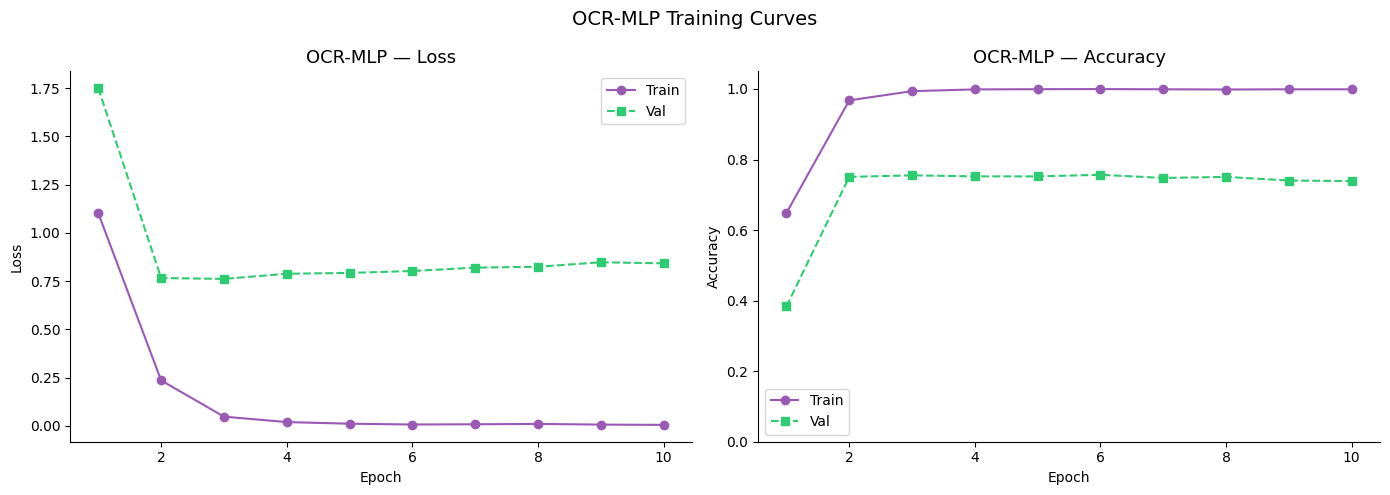

MLP Test Accuracy: 0.7380


In [ ]:
# ── MLP Training ──────────────────────────────────────────────────────────────
mlp_criterion = nn.CrossEntropyLoss()
mlp_optimizer = optim.Adam(mlp_model.parameters(), lr=1e-3, weight_decay=1e-4)
mlp_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    mlp_optimizer, mode='max', patience=3, factor=0.5)

print(f'Training MLP for {NUM_EPOCHS_MLP} epochs…\n')
mlp_history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_mlp_val_acc = 0.0

for epoch in range(1, NUM_EPOCHS_MLP + 1):
    tr_loss, tr_acc = train_one_epoch(
        mlp_model, text_train_loader, mlp_criterion, mlp_optimizer, DEVICE)
    vl_loss, vl_acc, _, _ = evaluate(
        mlp_model, text_val_loader, mlp_criterion, DEVICE)
    mlp_scheduler.step(vl_acc)

    mlp_history['train_loss'].append(tr_loss)
    mlp_history['val_loss'].append(vl_loss)
    mlp_history['train_acc'].append(tr_acc)
    mlp_history['val_acc'].append(vl_acc)

    if vl_acc > best_mlp_val_acc:
        best_mlp_val_acc = vl_acc
        torch.save(mlp_model.state_dict(), 'models/best_mlp.pth')
        saved_marker = ' ← saved'
    else:
        saved_marker = ''

    print(f'Epoch [{epoch:02d}/{NUM_EPOCHS_MLP}]  '
          f'Train Loss: {tr_loss:.4f}  Train Acc: {tr_acc:.4f}  '
          f'Val Loss: {vl_loss:.4f}  Val Acc: {vl_acc:.4f}{saved_marker}')

print(f'\n✅ Best Val Accuracy (MLP): {best_mlp_val_acc:.4f}')

# ── MLP training curves ───────────────────────────────────────────────────────
epochs_x = range(1, NUM_EPOCHS_MLP + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_x, mlp_history['train_loss'], 'o-', label='Train', color='#9B59B6')
ax1.plot(epochs_x, mlp_history['val_loss'],   's--', label='Val',  color='#2ECC71')
ax1.set_title('OCR-MLP — Loss', fontsize=13)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.spines[['top','right']].set_visible(False)

ax2.plot(epochs_x, mlp_history['train_acc'], 'o-', label='Train', color='#9B59B6')
ax2.plot(epochs_x, mlp_history['val_acc'],   's--', label='Val',  color='#2ECC71')
ax2.set_title('OCR-MLP — Accuracy', fontsize=13)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_ylim(0, 1.05); ax2.legend()
ax2.spines[['top','right']].set_visible(False)

plt.suptitle('OCR-MLP Training Curves', fontsize=14)
plt.tight_layout()
plt.savefig('results/mlp_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Final test evaluation ─────────────────────────────────────────────────────
mlp_model.load_state_dict(torch.load('models/best_mlp.pth', map_location=DEVICE))
_, mlp_test_acc, mlp_preds, mlp_true = evaluate(
    mlp_model, text_test_loader, mlp_criterion, DEVICE)
print(f'MLP Test Accuracy: {mlp_test_acc:.4f}')

---
## Section 7 — Evaluation & Comparison

Side-by-side comparison of CNN and OCR-MLP on the test set.

            Model  Best Val Acc  Test Acc           Input DL Framework
MobileNetV2 (CNN)      0.816845  0.810667    Image pixels      PyTorch
OCR-MLP (PyTorch)      0.756637  0.737991 TF-IDF from OCR      PyTorch


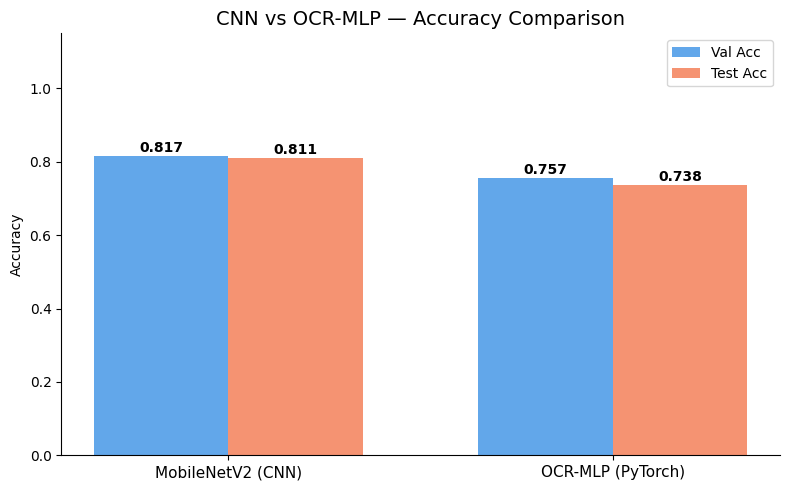

In [ ]:
# ── Accuracy comparison table ─────────────────────────────────────────────────
summary = pd.DataFrame({
    'Model': ['MobileNetV2 (CNN)', 'OCR-MLP (PyTorch)'],
    'Best Val Acc': [best_cnn_val_acc, best_mlp_val_acc],
    'Test Acc':     [cnn_test_acc,     mlp_test_acc],
    'Input':        ['Image pixels',   'TF-IDF from OCR'],
    'DL Framework': ['PyTorch',        'PyTorch'],
})
print('=' * 70)
print(summary.to_string(index=False))
print('=' * 70)
summary.to_csv('results/model_comparison.csv', index=False)

# ── Bar chart ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(2)
w = 0.35
b1 = ax.bar(x - w/2, summary['Best Val Acc'], w,
            label='Val Acc', color='#4C9BE8', alpha=0.88)
b2 = ax.bar(x + w/2, summary['Test Acc'], w,
            label='Test Acc', color='#F4845F', alpha=0.88)
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{bar.get_height():.3f}',
            ha='center', fontsize=10, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(summary['Model'], fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Accuracy')
ax.set_title('CNN vs OCR-MLP — Accuracy Comparison', fontsize=14)
ax.legend(); ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('results/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

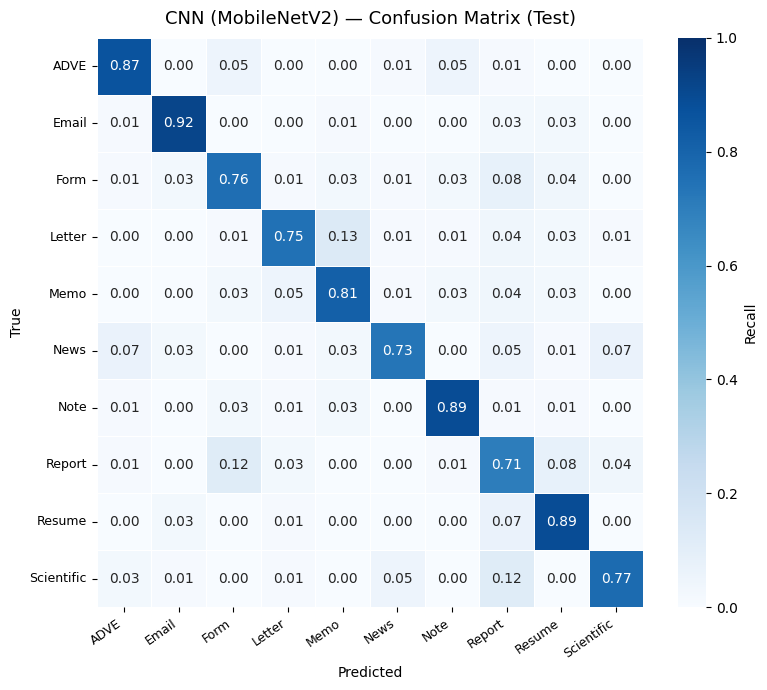

Saved → results/cm_cnn.png


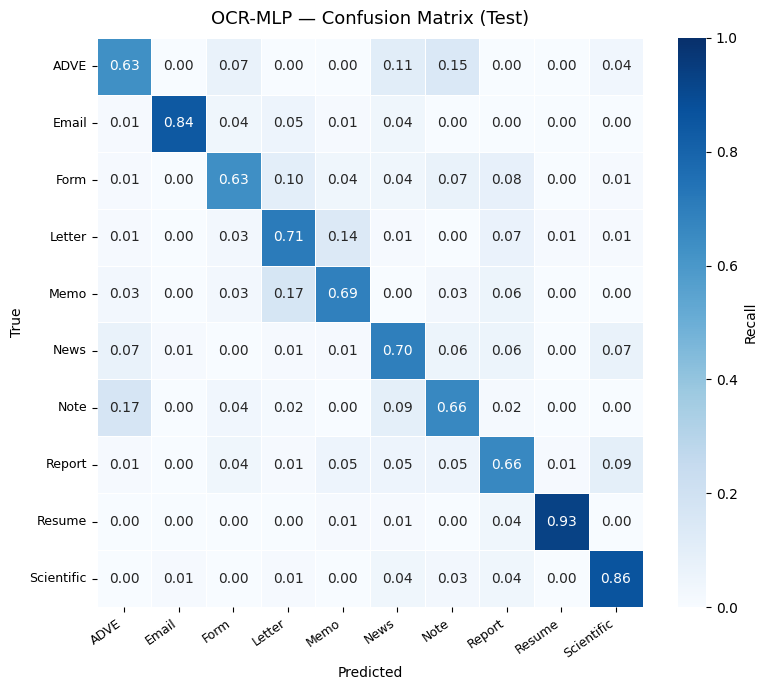

Saved → results/cm_mlp.png


In [ ]:
# ── Confusion matrices ────────────────────────────────────────────────────────
def plot_confusion_matrix(y_true, y_pred, class_names, title, save_path):
    cm   = confusion_matrix(y_true, y_pred)
    norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    n    = len(class_names)
    fig, ax = plt.subplots(figsize=(max(8, n*0.8), max(6, n*0.7)))
    sns.heatmap(norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.4, vmin=0, vmax=1, ax=ax,
                cbar_kws={'label': 'Recall'})
    ax.set_title(title, fontsize=13, pad=10)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    plt.xticks(rotation=35, ha='right', fontsize=9)
    plt.yticks(rotation=0, fontsize=9)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved → {save_path}')


plot_confusion_matrix(
    cnn_true, cnn_preds, CLASS_NAMES,
    'CNN (MobileNetV2) — Confusion Matrix (Test)',
    'results/cm_cnn.png'
)

plot_confusion_matrix(
    mlp_true, mlp_preds, list(ocr_classes),
    'OCR-MLP — Confusion Matrix (Test)',
    'results/cm_mlp.png'
)

In [ ]:
# ── Classification reports ────────────────────────────────────────────────────
print('=' * 55)
print('  CNN (MobileNetV2) — Classification Report')
print('=' * 55)
print(classification_report(cnn_true, cnn_preds, target_names=CLASS_NAMES))

print('=' * 55)
print('  OCR-MLP — Classification Report')
print('=' * 55)
print(classification_report(mlp_true, mlp_preds, target_names=list(ocr_classes)))

# Save to file
with open('results/classification_reports.txt', 'w') as f:
    f.write('CNN (MobileNetV2)\n')
    f.write(classification_report(cnn_true, cnn_preds, target_names=CLASS_NAMES))
    f.write('\nOCR-MLP\n')
    f.write(classification_report(mlp_true, mlp_preds, target_names=list(ocr_classes)))
print('Saved → results/classification_reports.txt')

  CNN (MobileNetV2) — Classification Report
              precision    recall  f1-score   support

        ADVE       0.86      0.87      0.86        75
       Email       0.91      0.92      0.91        75
        Form       0.76      0.76      0.76        75
      Letter       0.84      0.75      0.79        75
        Memo       0.78      0.81      0.80        75
        News       0.87      0.73      0.80        75
        Note       0.87      0.89      0.88        75
      Report       0.61      0.71      0.65        75
      Resume       0.80      0.89      0.84        75
  Scientific       0.87      0.77      0.82        75

    accuracy                           0.81       750
   macro avg       0.82      0.81      0.81       750
weighted avg       0.82      0.81      0.81       750

  OCR-MLP — Classification Report
              precision    recall  f1-score   support

        ADVE       0.63      0.63      0.63        54
       Email       0.97      0.84      0.90        75
